
Top 5 states by mining reports:
       State_clean  mining_incidents
43  madhya pradesh               279
54     maharashtra               182
85      tamil nadu               120
21         gujarat               114
0   andhra pradesh                99

Merged Top 5 Data:
      State_clean  mining_incidents  police_total
0  andhra pradesh                99        5190.0
1         gujarat               114         223.0
2  madhya pradesh               279         523.0
3     maharashtra               182        5292.0
4      tamil nadu               120        9843.0


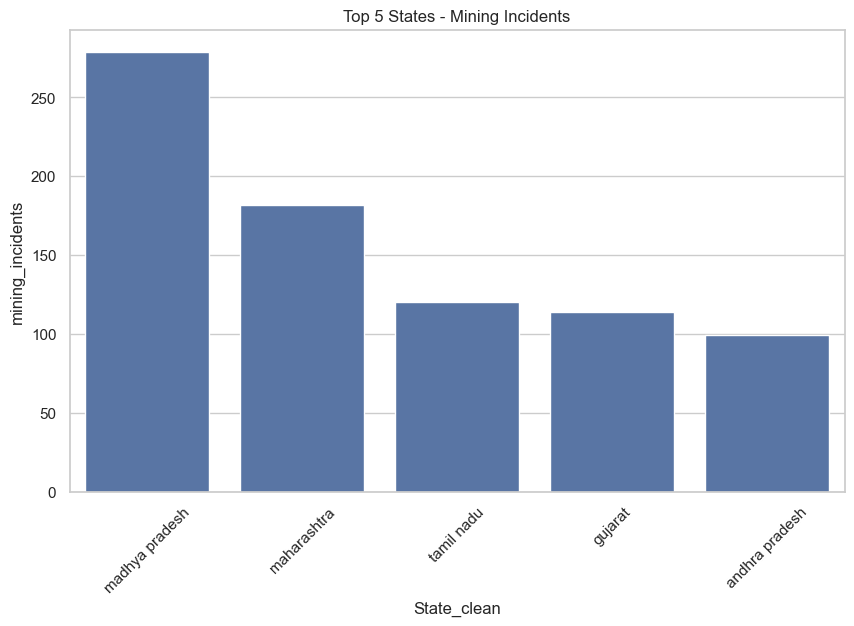

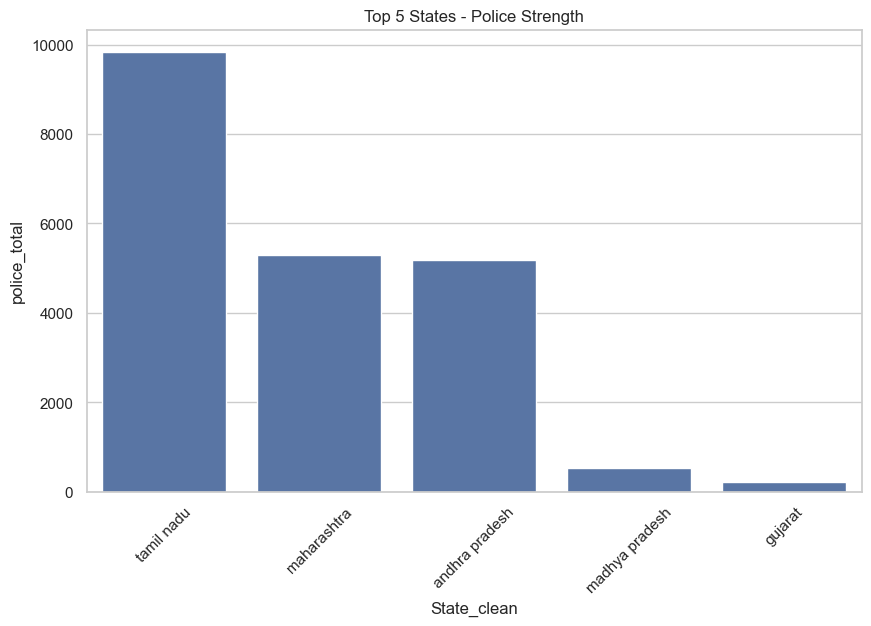

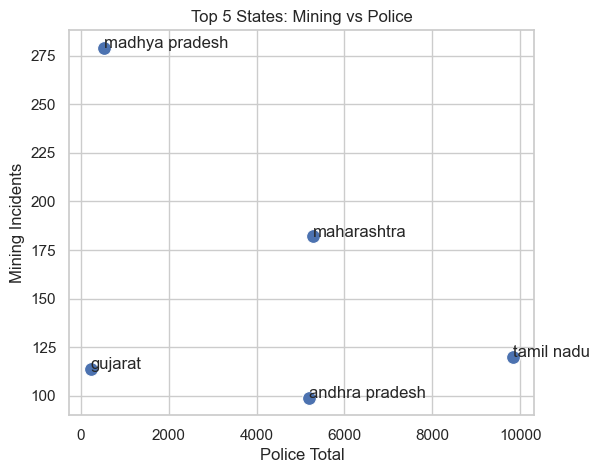


Mining incidents per police personnel:
      State_clean  mining_incidents  police_total  mining_per_police
2  madhya pradesh               279         523.0           0.533461
1         gujarat               114         223.0           0.511211
3     maharashtra               182        5292.0           0.034392
0  andhra pradesh                99        5190.0           0.019075
4      tamil nadu               120        9843.0           0.012191

Saved to top5_mining_police_analysis.csv


In [20]:
# comparing police officers to mining reports in top 5 states 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
mining = pd.read_csv("data/indiasandwatch/mining_news_reporrts.csv")
police = pd.read_csv("data/crime/police personnel.csv")

def clean_state(s):
    if pd.isna(s):
        return s
    return s.strip().lower()

mining['State_clean'] = mining['States'].apply(clean_state)
police['State_clean'] = police['State'].apply(clean_state)

mining_counts = (
    mining.groupby('State_clean')
    .size()
    .reset_index(name='mining_incidents')
    .sort_values(by='mining_incidents', ascending=False)
)

top5_states = mining_counts.head(5)['State_clean'].tolist()

print("\nTop 5 states by mining reports:")
print(mining_counts.head(5))

mining_top = mining[mining['State_clean'].isin(top5_states)]

mining_agg = (
    mining_top.groupby('State_clean')
    .size()
    .reset_index(name='mining_incidents')
)
exclude_cols = ['Country', 'State', 'Year', 'As On Date', 'State_clean']
personnel_cols = [col for col in police.columns if col not in exclude_cols]

for col in personnel_cols:
    police[col] = pd.to_numeric(police[col], errors='coerce')

police['police_total'] = police[personnel_cols].sum(axis=1)

latest_year = police['Year'].max()
police = police[police['Year'] == latest_year]

# top 5 states
police_top = police[police['State_clean'].isin(top5_states)]

police_agg = (
    police_top.groupby('State_clean')['police_total']
    .sum()
    .reset_index()
)

df = pd.merge(mining_agg, police_agg, on='State_clean', how='inner')

print("\nMerged Top 5 Data:")
print(df)


plt.figure(figsize=(10,6))

sns.barplot(
    data=df.sort_values('mining_incidents', ascending=False),
    x='State_clean',
    y='mining_incidents'
)

plt.title("Top 5 States - Mining Incidents")
plt.xticks(rotation=45)
plt.show()


plt.figure(figsize=(10,6))

sns.barplot(
    data=df.sort_values('police_total', ascending=False),
    x='State_clean',
    y='police_total'
)

plt.title("Top 5 States - Police Strength")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df,
    x='police_total',
    y='mining_incidents',
    s=100
)

for i, row in df.iterrows():
    plt.text(row['police_total'], row['mining_incidents'], row['State_clean'])

plt.title("Top 5 States: Mining vs Police")
plt.xlabel("Police Total")
plt.ylabel("Mining Incidents")
plt.show()

df['mining_per_police'] = df['mining_incidents'] / df['police_total']

print("\nMining incidents per police personnel:")
print(df.sort_values('mining_per_police', ascending=False))


if 'Start Date' in mining.columns:
    mining['Start Date'] = pd.to_datetime(mining['Start Date'], errors='coerce')
    mining_top = mining[mining['State_clean'].isin(top5_states)]

    mining_top['year'] = mining_top['Start Date'].dt.year

    trend = (
        mining_top.groupby(['year', 'State_clean'])
        .size()
        .reset_index(name='count')
    )

    plt.figure(figsize=(10,6))

    sns.lineplot(
        data=trend,
        x='year',
        y='count',
        hue='State_clean'
    )

    plt.title("Mining Trends Over Time (Top 5 States)")
    plt.show()

df.to_csv("top5_mining_police_analysis.csv", index=False)
print("\nSaved to top5_mining_police_analysis.csv")

police/crime reports are not the main driver of where mining happens. There might be some state wise correlation with respect to police involvement but without studying each individual district's police patterns (data we do not have), this is inconclusive.

Top 5 states: ['madhya pradesh', 'maharashtra', 'tamil nadu', 'gujarat', 'andhra pradesh']

Final DF:
      State_clean  mining_incidents  log_mining  Dilapidated    Good  \
0  andhra pradesh                99    4.605170        1.845  75.435   
1         gujarat               114    4.744932        1.400  71.885   
2  madhya pradesh               279    5.634790        2.920  65.545   
3     maharashtra               182    5.209486        2.455  67.870   
4      tamil nadu               120    4.795791        0.950  83.170   

   Liveable  housing_quality_index  
0    22.720                 73.590  
1    26.710                 70.485  
2    31.535                 62.625  
3    29.665                 65.415  
4    15.880                 82.220  


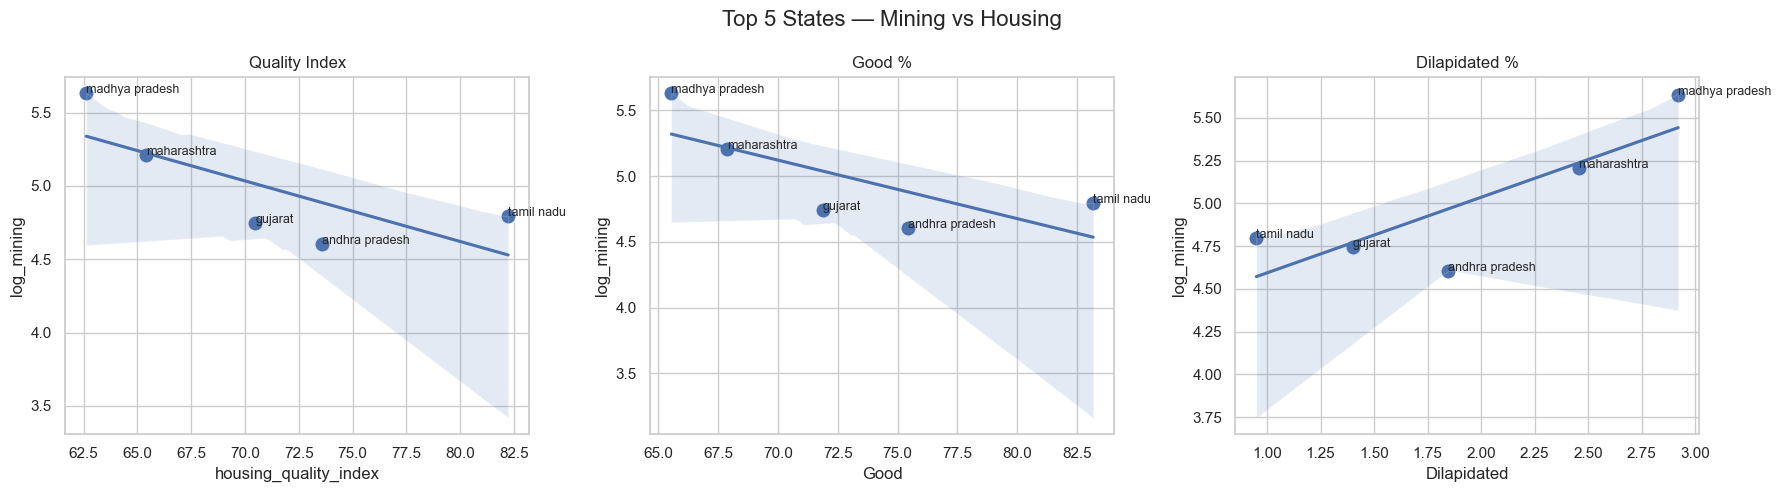

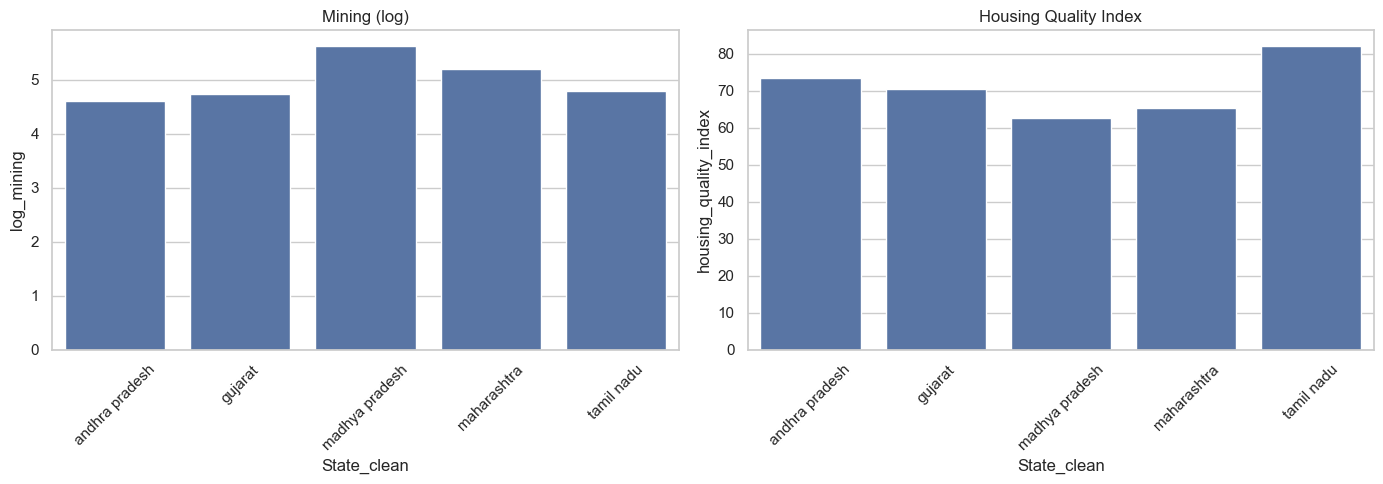


Correlations (top 5 only):
                       log_mining  housing_quality_index      Good  \
log_mining               1.000000              -0.750339 -0.733192   
housing_quality_index   -0.750339               1.000000  0.998954   
Good                    -0.733192               0.998954  1.000000   
Dilapidated              0.830816              -0.916147 -0.896855   

                       Dilapidated  
log_mining                0.830816  
housing_quality_index    -0.916147  
Good                     -0.896855  
Dilapidated               1.000000  
Saved to top5_housing_mining_analysis.csv


In [30]:
# housing data analysis for top 5 states 

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

mining = pd.read_csv("data/indiasandwatch/mining_news_reporrts.csv")
house = pd.read_csv("data/household.csv")

def clean_state(s):
    if pd.isna(s):
        return s
    return s.strip().lower()

mining['State_clean'] = mining['States'].apply(clean_state)
house['State_clean'] = house['State'].apply(clean_state)

mining_agg = (
    mining.groupby('State_clean')
    .size()
    .reset_index(name='mining_incidents')
)

top5_states = (
    mining_agg
    .sort_values('mining_incidents', ascending=False)
    .head(5)['State_clean']
    .tolist()
)

print("Top 5 states:", top5_states)

mining_top = mining_agg[mining_agg['State_clean'].isin(top5_states)].copy()
mining_top['log_mining'] = np.log1p(mining_top['mining_incidents'])

condition_col = 'Condition Of House'
value_col = [c for c in house.columns if 'Percentage' in c][0]

house[value_col] = pd.to_numeric(house[value_col], errors='coerce')

house_pivot = house.pivot_table(
    index='State_clean',
    columns=condition_col,
    values=value_col,
    aggfunc='mean'
).reset_index()

house_pivot.columns.name = None

house_top = house_pivot[house_pivot['State_clean'].isin(top5_states)]

df = pd.merge(mining_top, house_top, on='State_clean', how='inner')

good_col = [c for c in df.columns if 'good' in c.lower()][0]
bad_col = [c for c in df.columns if 'dilapidated' in c.lower()][0]

df['housing_quality_index'] = df[good_col] - df[bad_col]

print("\nFinal DF:")
print(df)

fig, axes = plt.subplots(1, 3, figsize=(18,5))

plots = [
    ('housing_quality_index', 'Quality Index'),
    (good_col, 'Good %'),
    (bad_col, 'Dilapidated %')
]

for ax, (col, title) in zip(axes, plots):
    
    sns.scatterplot(data=df, x=col, y='log_mining', s=120, ax=ax)
    sns.regplot(data=df, x=col, y='log_mining', scatter=False, ax=ax)
    
    for _, row in df.iterrows():
        ax.text(row[col], row['log_mining'], row['State_clean'], fontsize=9)
    
    ax.set_title(title)

plt.suptitle("Top 5 States — Mining vs Housing", fontsize=16)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.barplot(data=df, x='State_clean', y='log_mining', ax=axes[0])
axes[0].set_title("Mining (log)")

sns.barplot(data=df, x='State_clean', y='housing_quality_index', ax=axes[1])
axes[1].set_title("Housing Quality Index")

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nCorrelations (top 5 only):")
print(df[['log_mining', 'housing_quality_index', good_col, bad_col]].corr())

df.to_csv("top5_housing_mining_analysis.csv", index=False)
print("Saved to top5_housing_mining_analysis.csv")

Points to illegal extraction being more prevalent in less developed regions 

Top 5 states: ['madhya pradesh', 'maharashtra', 'tamil nadu', 'gujarat', 'andhra pradesh']

Final merged DF:
      State_clean  log_mining  literacy_rate  marginal_worker_ratio  \
0  andhra pradesh    4.605170       0.602294               0.163055   
1         gujarat    4.744932       0.679967               0.177721   
2  madhya pradesh    5.634790       0.590022               0.280971   
3     maharashtra    5.209486       0.723269               0.116110   
4      tamil nadu    4.795791       0.718498               0.150298   

   agri_dependence  
0         0.507155  
1         0.373093  
2         0.470189  
3         0.468142  
4         0.337223  


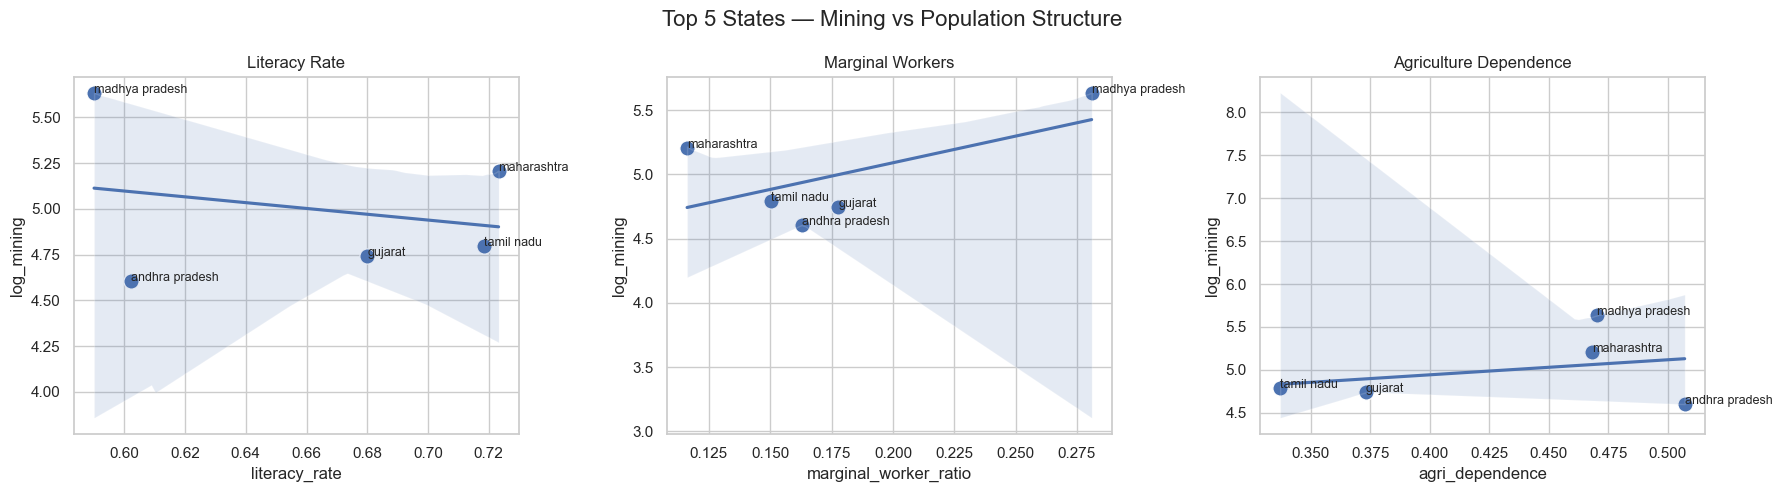


Correlations (top 5 only):
                       log_mining  literacy_rate  marginal_worker_ratio  \
log_mining               1.000000      -0.238266               0.612054   
literacy_rate           -0.238266       1.000000              -0.755981   
marginal_worker_ratio    0.612054      -0.755981               1.000000   
agri_dependence          0.300106      -0.625465               0.179099   

                       agri_dependence  
log_mining                    0.300106  
literacy_rate                -0.625465  
marginal_worker_ratio         0.179099  
agri_dependence               1.000000  


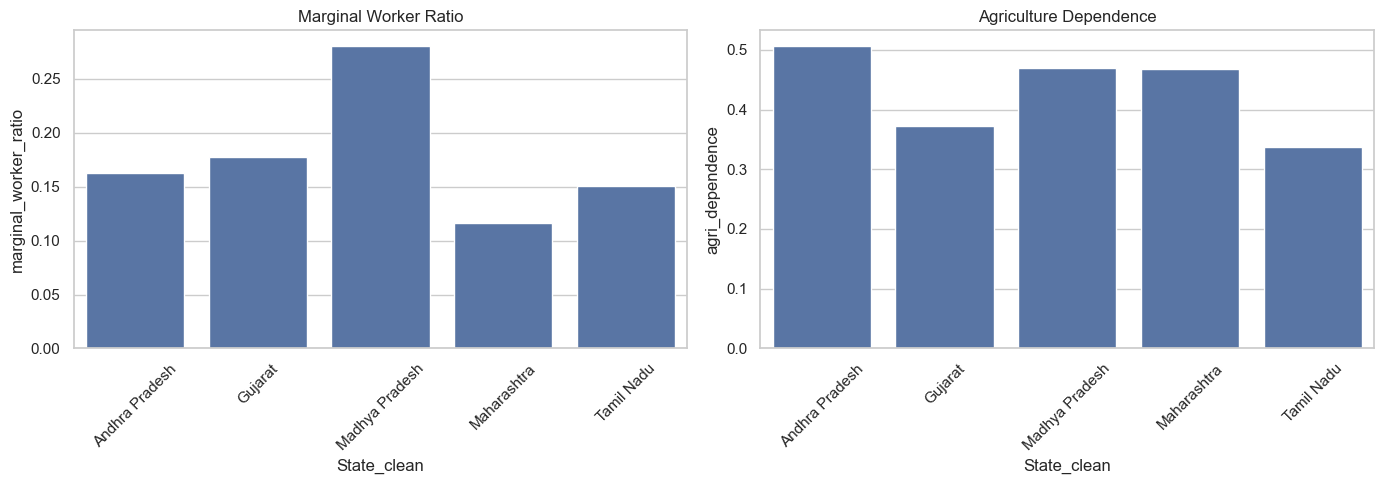

In [33]:
#population data 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

mining = pd.read_csv("data/indiasandwatch/mining_news_reporrts.csv")
pop = pd.read_csv("data/population.csv")  

def clean_state(s):
    if pd.isna(s):
        return s
    return s.strip().lower()

mining['State_clean'] = mining['States'].apply(clean_state)
pop['State_clean'] = pop['State'].apply(clean_state)

mining_agg = (
    mining.groupby('State_clean')
    .size()
    .reset_index(name='mining_incidents')
)

top5_states = (
    mining_agg
    .sort_values('mining_incidents', ascending=False)
    .head(5)['State_clean']
    .tolist()
)

print("Top 5 states:", top5_states)

mining_top = mining_agg[mining_agg['State_clean'].isin(top5_states)].copy()
mining_top['log_mining'] = np.log1p(mining_top['mining_incidents'])

cols = [
    'State_clean',
    'Population (UOM:Number), Scaling Factor:1',
    'Literate Population  (UOM:Number), Scaling Factor:1',
    'Working Population (UOM:Number), Scaling Factor:1',
    'Number Of Marginal Workers (UOM:Number), Scaling Factor:1',
    'Number Of Main Workers As Agricultural Labourers (UOM:Number), Scaling Factor:1',
    'Number Of Main Workers As Cultivators (UOM:Number), Scaling Factor:1'
]

df_pop = pop[cols].copy()

for c in cols[1:]:
    df_pop[c] = pd.to_numeric(df_pop[c], errors='coerce')

state_pop = df_pop.groupby('State_clean').sum().reset_index()

state_pop = state_pop[state_pop['State_clean'].isin(top5_states)]

state_pop['literacy_rate'] = (
    state_pop['Literate Population  (UOM:Number), Scaling Factor:1'] /
    state_pop['Population (UOM:Number), Scaling Factor:1']
)

state_pop['marginal_worker_ratio'] = (
    state_pop['Number Of Marginal Workers (UOM:Number), Scaling Factor:1'] /
    state_pop['Working Population (UOM:Number), Scaling Factor:1']
)

state_pop['agri_dependence'] = (
    state_pop['Number Of Main Workers As Agricultural Labourers (UOM:Number), Scaling Factor:1'] +
    state_pop['Number Of Main Workers As Cultivators (UOM:Number), Scaling Factor:1']
) / state_pop['Working Population (UOM:Number), Scaling Factor:1']

df = pd.merge(mining_top, state_pop, on='State_clean', how='inner')

print("\nFinal merged DF:")
print(df[['State_clean', 'log_mining', 'literacy_rate', 'marginal_worker_ratio', 'agri_dependence']])

fig, axes = plt.subplots(1, 3, figsize=(18,5))

features = [
    ('literacy_rate', 'Literacy Rate'),
    ('marginal_worker_ratio', 'Marginal Workers'),
    ('agri_dependence', 'Agriculture Dependence')
]

for ax, (col, title) in zip(axes, features):
    
    sns.scatterplot(data=df, x=col, y='log_mining', s=120, ax=ax)
    sns.regplot(data=df, x=col, y='log_mining', scatter=False, ax=ax)
    
    for _, row in df.iterrows():
        ax.text(row[col], row['log_mining'], row['State_clean'], fontsize=9)
    
    ax.set_title(title)

plt.suptitle("Top 5 States — Mining vs Population Structure", fontsize=16)
plt.tight_layout()
plt.show()

print("\nCorrelations (top 5 only):")
print(df[['log_mining', 'literacy_rate', 'marginal_worker_ratio', 'agri_dependence']].corr())

df['State_clean'] = df['State_clean'].str.title()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.barplot(data=df, x='State_clean', y='marginal_worker_ratio', ax=axes[0])
axes[0].set_title("Marginal Worker Ratio")

sns.barplot(data=df, x='State_clean', y='agri_dependence', ax=axes[1])
axes[1].set_title("Agriculture Dependence")

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Mining is most strongly associated with marginal worker ratio (unstable, seasonal employment)

In [37]:
 pip install statsmodels.api

ERROR: Could not find a version that satisfies the requirement statsmodels.api (from versions: none)
ERROR: No matching distribution found for statsmodels.api
Note: you may need to restart the kernel to use updated packages.


In [34]:
import statsmodels.api as sm

features = ['literacy_rate', 'marginal_worker_ratio', 'agri_dependence']
X = df[features]
y = df['log_mining']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

ModuleNotFoundError: No module named 'statsmodels'